# Annotate Classes from Masks

This notebook is used to add class information based on the contrast of flakes to the annotated flakes from a given directory of images and masks.

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple

from zpreprocessor_functions import get_instance_contrasts_from_dir
from zclass_annotator import Class_Annotator

In [2]:
def filter_high_stddev(instance_contrasts, classifiers, threshold=0.1):
    accepted_indices = []
    for i, d in enumerate(instance_contrasts):
        if np.max(np.std(d, axis=0)) < 0.1:
            accepted_indices.append(i)
    instance_contrasts = [instance_contrasts[i] for i in accepted_indices]
    classifiers = [classifiers[i] for i in accepted_indices]
    return instance_contrasts, classifiers


def instance_masks_to_semantic_masks(
    mask_directory: str,
    mask_save_directory: str,
    instance_classifiers: List[Tuple[str, int]],
    instance_classes: List[int],
) -> None:
    # extract all unique mask names
    mask_names = set([mask_name for mask_name, _ in instance_classifiers])

    for idx, mask_name in enumerate(mask_names):
        print(f"{idx + 1}/{len(mask_names)} Processed", end="\r")

        mask_path = os.path.join(mask_directory, mask_name)
        mask = cv2.imread(mask_path, 0)

        assert mask is not None, f"Could not load mask {mask_path}"

        semantic_mask = np.zeros_like(mask)
        for instance_class, (classifier_name, classifier_id) in zip(
            instance_classes, instance_classifiers
        ):
            if classifier_name == mask_name:
                semantic_mask[mask == classifier_id] = instance_class

        cv2.imwrite(os.path.join(mask_save_directory, mask_name), semantic_mask)

    print(
        f"\nAdded {len([instance_class for instance_class in instance_classes if instance_class != 0])} instances to the instance masks"
    )
    

def plot_contrast_scatter(class_contrasts, axis_names, figsize=(15, 5)):
    """
    Plot scatter plots of contrast values for different classes.
    
    Parameters:
    - class_contrasts: dict mapping class_id to contrast arrays
    - axis_names: list of axis names for BGR channels
    - figsize: tuple for figure size
    """
    
    fig, axs = plt.subplots(1, 3, figsize=figsize)
    
    # RG contrast plot
    ax = axs[0]
    for class_id, contrasts in class_contrasts.items():
        if class_id == 0:
            continue
        ax.scatter(
            contrasts[:, 2], #red
            contrasts[:, 1], #green
            label=f"Class {class_id}",
            alpha=1 / 255,
            ec="none",
        )
    ax.set_xlabel(axis_names[2])
    ax.set_ylabel(axis_names[1])
    leg = ax.legend()
    for point in leg.legend_handles:
        point.set_alpha(1)
    ax.set_title("RG Contrast")
    
    # GB contrast plot
    ax = axs[1]
    for class_id, contrasts in class_contrasts.items():
        if class_id == 0:
            continue
        ax.scatter(
            contrasts[:, 1], #green
            contrasts[:, 0], #blue
            label=f"Class {class_id}",
            alpha=1 / 255,
            ec="none",
        )
    ax.set_xlabel(axis_names[1])
    ax.set_ylabel(axis_names[0])
    leg = ax.legend()
    for point in leg.legend_handles:
        point.set_alpha(1)
    ax.set_title("GB Contrast")
    
    # BR contrast plot
    ax = axs[2]
    for class_id, contrasts in class_contrasts.items():
        if class_id == 0:
            continue
        ax.scatter(
            contrasts[:, 0], #blue
            contrasts[:, 2], #red
            label=f"Class {class_id}",
            alpha=1 / 255,
            ec="none",
        )
    ax.set_xlabel(axis_names[0])
    ax.set_ylabel(axis_names[2])
    leg = ax.legend()
    for point in leg.legend_handles:
        point.set_alpha(1)
    ax.set_title("BR Contrast")
    
    plt.tight_layout()
    plt.show()

## Setting some constants

| Parameter                 | Description                                                                                                                              |
| ------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| `IMAGE_DIRECTORY`         | The directory path of the saved images; the images need to be in `.jpg` or `.png` format                                                 |
| `INSTANCE_MASK_DIRECTORY` | The directory where the instance masks are located, each pixel value denotes a different flake, the masks need to be in `.png` format.   |
| `SEMANTIC_MASK_DIRECTORY` | The directory where the semantic masks will be saved, each pixel value denotes a different class. The masks need to be in `.png` format. |
| `USE_FLATFIELD`           | Whether to use a flatfield image or not                                                                                                  |
| `FLATFIELD_PATH`          | The path to the flatfield image                                                                                                          |
| `USED_CHANNELS `          | The channels used to fit the GM-Model, if, for example, your blue channel is weak you may want to only use `RG`                          |
| `AXIS_NAMES`              | The names used when plotting for the axes                                                                                                |

As the supplied datasets already have their flatfield removed, the default for `USE_FLATFIELD` is set to `False`.  
If you want to use a flatfield image, you need to set `USE_FLATFIELD` to `True` and set the path to the flatfield image in `FLATFIELD_PATH`.


In [18]:
IMAGE_DIRECTORY = "Materials/CCPS/images"
INSTANCE_MASK_DIRECTORY = "Materials/CCPS/masks"  # You need to provide the path to the instance masks directory, this does not currently exist
SEMANTIC_MASK_DIRECTORY = "Materials/CCPS/semantic_masks"  # The directory where the semantic masks will be saved

USE_FLATFIELD = False
FLATFIELD_PATH = None
USED_CHANNELS = "BGR"
AXIS_NAMES = ["Blue Contrast", "Green Contrast", "Red Contrast"]

## Checking if the given Parameters are valid


In [19]:
assert os.path.exists(IMAGE_DIRECTORY), "Image directory does not exist"
assert os.path.exists(INSTANCE_MASK_DIRECTORY), "Mask directory does not exist"
if USE_FLATFIELD:
    assert os.path.exists(FLATFIELD_PATH), "Flatfield image does not exist"

assert len(USED_CHANNELS) in [2, 3], "We need 2 or 3 channels for the GMM"

os.makedirs(SEMANTIC_MASK_DIRECTORY, exist_ok=True)

## Loading the Contrast Values into Memory

The `get_contast_from_dir` function checks the directory for masks and their corresponding images.  
If the `USE_FLATFIELD` is enabled it will also look for the flatfield image and remove it from the image.  
If the images already have their flatfield removed set it to `False`.


In [30]:
instance_contrasts, instance_classifiers = get_instance_contrasts_from_dir(
    image_directory=IMAGE_DIRECTORY,
    mask_directory=INSTANCE_MASK_DIRECTORY,
    use_flatfield=USE_FLATFIELD,
    flatfield_path=FLATFIELD_PATH,
)
#instance_contrasts, instance_classifiers = filter_high_stddev(instance_contrasts, instance_classifiers, threshold=0.1)

1/24
2/24
3/24
4/24
5/24
6/24
7/24
8/24
9/24
10/24
11/24
12/24
13/24
14/24
15/24
16/24
17/24
18/24
19/24
20/24
21/24
22/24
23/24
24/24


In [31]:
# Add this cell before running the Class_Annotator
print(f"Instance mask directory exists: {os.path.exists(INSTANCE_MASK_DIRECTORY)}")
if os.path.exists(INSTANCE_MASK_DIRECTORY):
    mask_files = [f for f in os.listdir(INSTANCE_MASK_DIRECTORY) if f.endswith('.png')]
    print(f"Found {len(mask_files)} PNG files in instance mask directory")
    print(f"First few files: {mask_files[:5]}")
else:
    print("Instance mask directory does not exist!")
# Add this cell to debug the data loading
print(f"Number of instance contrasts: {len(instance_contrasts)}")
print(f"Number of instance classifiers: {len(instance_classifiers)}")

if len(instance_contrasts) == 0:
    print("No instance contrasts found! Check your instance masks.")
else:
    print(f"First few instance contrasts shapes: {[arr.shape for arr in instance_contrasts[:3]]}")

Instance mask directory exists: True
Found 24 PNG files in instance mask directory
First few files: ['32d9b9ee-s2_f02_2.png', '3d979b73-s3_f01_2.png', '4774eeb4-s5_f10_2.png', '50b503d4-s2_f05_2.png', '620a17ca-s1_f01_2.png']
Number of instance contrasts: 150
Number of instance classifiers: 150
First few instance contrasts shapes: [(2193, 3), (1059, 3), (757, 3)]


## Annotating the clusters of classes

The `Class_Annotator` class is used to annotate the clusters of classes based on the contrast values of the flakes.
It opens 3 windows: The RG contrast plot, the GB contrast plot, and the BR contrast plot.

### Controls

You can circle clusters of points using your mouse in any of the three windows and it will automatically translate the points to the other two windows.

|     Keys     | Description                            |
| :----------: | -------------------------------------- |
| <kbd>D</kbd> | Increament current Class ID            |
| <kbd>A</kbd> | Decrement current Class ID             |
| <kbd>X</kbd> | Set current Class ID to 0 (Background) |
| <kbd>Q</kbd> | Exit the program                       |


In [32]:
%matplotlib qt

CA = Class_Annotator(
    instance_contrasts,
    plot_alpha=1,  # Set to 1 for better visibility
    plot_s=50,  # This is the size of the points in the plot
    display_std=True,  # Display the standard deviation of the points in the plot
    upper_bounds=[0.5, 0.5, 0.5],  # Upper bounds for the contrast values in BGR
    lower_bounds=[-1.0, -1.0, -1.0],  # Lower bounds for the contrast values in BGR
)

CA.run()

In [33]:
instance_classes = CA.get_results()
unique_instance_classes = np.unique(instance_classes)
class_contrasts = {cls_id: [] for cls_id in unique_instance_classes}

for instance_contrast, class_id in zip(instance_contrasts, instance_classes):
    class_contrasts[class_id].extend(instance_contrast)

for class_id, contrasts in class_contrasts.items():
    class_contrasts[class_id] = np.array(contrasts)
    print(f"Class {class_id} has {len(contrasts)} instances")

Class 1 has 171930 instances


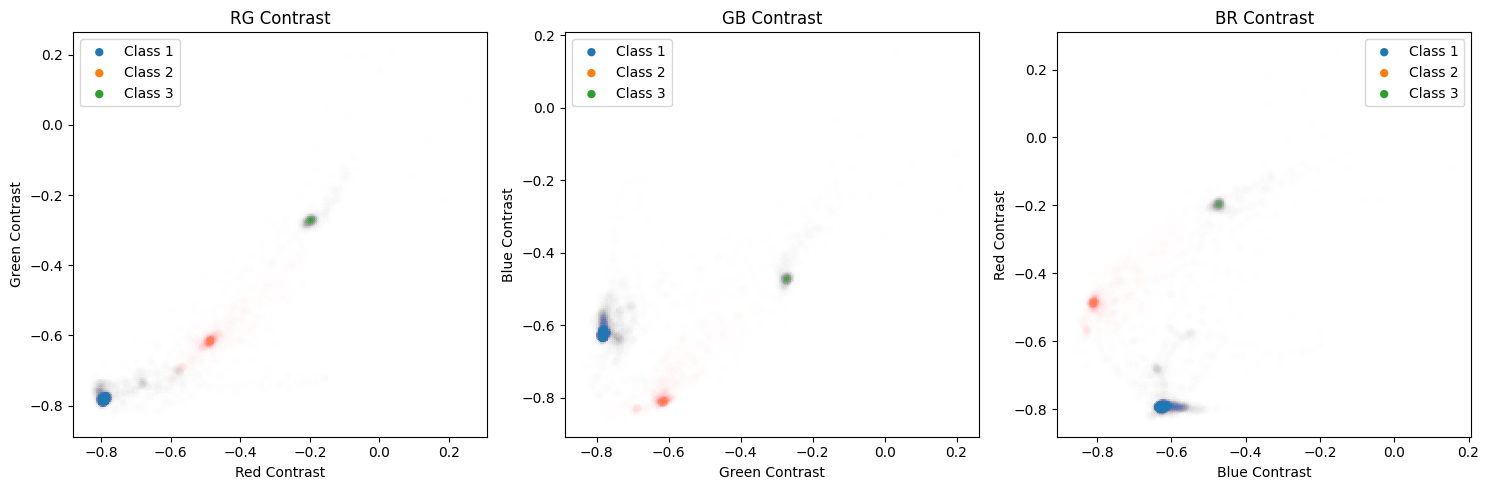

In [28]:
%matplotlib inline

plot_contrast_scatter(class_contrasts, AXIS_NAMES)

In [29]:
# Now saves the semantic masks based on the instance classifiers and classes
instance_masks_to_semantic_masks(
    mask_directory=INSTANCE_MASK_DIRECTORY,
    mask_save_directory=SEMANTIC_MASK_DIRECTORY,
    instance_classifiers=instance_classifiers,
    instance_classes=instance_classes,
)

4/4 Processed
Added 4 instances to the instance masks
